<div style="box-sizing:border-box;width:100%;margin:12px 0 28px;padding:38px 40px;border:1px solid rgba(255,255,255,.14);border-radius:22px;background:radial-gradient(circle at 92% 10%,rgba(255,255,255,.14) 0 7%,transparent 8%),linear-gradient(125deg,#0b1f3a 0%,#164e63 58%,#0f9d91 100%);color:#ffffff;font-family:Inter,'Segoe UI',Arial,sans-serif;box-shadow:0 14px 35px rgba(16,42,67,.24);overflow:hidden;">
  <div style="display:inline-block;margin:0 0 15px;padding:7px 13px;border:1px solid rgba(255,255,255,.30);border-radius:999px;background:rgba(255,255,255,.13);color:#ffffff;font-size:11px;font-weight:800;line-height:1.2;letter-spacing:.07em;text-transform:uppercase;">Avance reproducible · 75%</div>
  <div style="margin:0 0 7px;color:#ffffff;font-size:38px;font-weight:800;line-height:1.15;letter-spacing:-.02em;">Laboratorio 5</div>
  <div style="margin:0 0 12px;color:rgba(255,255,255,.93);font-size:21px;font-weight:500;line-height:1.4;">Minería de Textos y Análisis de Sentimientos</div>
  <div style="max-width:880px;margin:0;color:rgba(255,255,255,.80);font-size:15px;line-height:1.65;">Clasificación de tweets sobre desastres reales mediante NLP y aprendizaje automático.</div>
  <div style="width:72px;height:4px;margin:22px 0;background:linear-gradient(90deg,#f59e0b,rgba(255,255,255,.85));border-radius:999px;"></div>
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(210px,1fr));gap:11px;margin:0;">
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Jorge Gabriel Palacios Sales</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 231385</span>
    </div>
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Pablo Daniel Barillas Moreno</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 22193</span>
    </div>
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Roberto Emiliano Otoniel</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 23968</span>
    </div>
  </div>
  <div style="display:flex;flex-wrap:wrap;gap:8px 18px;margin-top:22px;padding-top:17px;border-top:1px solid rgba(255,255,255,.20);color:rgba(255,255,255,.78);font-size:12px;line-height:1.5;">
    <span style="color:#ffffff;font-weight:750;">Universidad del Valle de Guatemala</span>
    <span>Data Science</span>
    <span>Sección 10</span>
    <span>Grupo 1</span>
  </div>
</div>

<div class="section"><h2>1 · Alcance y reproducibilidad</h2></div>

Este avance cubre la descripción de los datos, limpieza explicada, exploración, probabilidades de unigramas, bigramas y trigramas, comparación preliminar de modelos, función de inferencia y una primera lectura de sentimiento. Todas las cifras que se muestran provienen de los artefactos generados por `scripts/run_advance.py`; no se escribieron manualmente en el notebook.

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Image, display
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "train.csv").exists():
    ROOT = ROOT.parent

TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

# CSS también incrustado desde código para conservar el estilo en ejecución.
display(HTML(
    "<style>"
    ".metric-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin:14px 0}"
    ".metric{padding:16px;border-radius:14px;background:#f8fbff;border:1px solid #d8e6f5;text-align:center}"
    ".metric b{display:block;font-size:1.55rem;color:#2563eb}.ok{color:#047857;font-weight:700}"
    "</style>"
))
print(f"Raíz del proyecto: {ROOT}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Daniel Barillas\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Raíz del proyecto: C:\Users\Daniel Barillas\Desktop\Laboratorio-4.-Analisis-Geoespacial-y-sensores-remotos_DS\Laboratorio-5.-Mineria-de-Textos-y-Analisis-de-Sentimientos_DS_Grupo-1


<div class="section"><h2>2 · Datos y análisis exploratorio</h2></div>

,target,tweets,categoria,porcentaje
0,0,4342,No desastre,57.03%
1,1,3271,Desastre real,42.97%


,variable,tipo,faltantes,faltantes_pct,valores_unicos
0,id,int64,0,0.000000,7613
1,keyword,str,61,0.801261,221
2,location,str,2533,33.272035,3341
3,text,str,0,0.000000,7503
4,target,int64,0,0.000000,2
5,clean_text,str,0,0.000000,6772
6,char_count,int64,0,0.000000,147
7,word_count,int64,0,0.000000,31
8,clean_word_count,int64,0,0.000000,22
9,unique_word_ratio,float64,0,0.000000,97


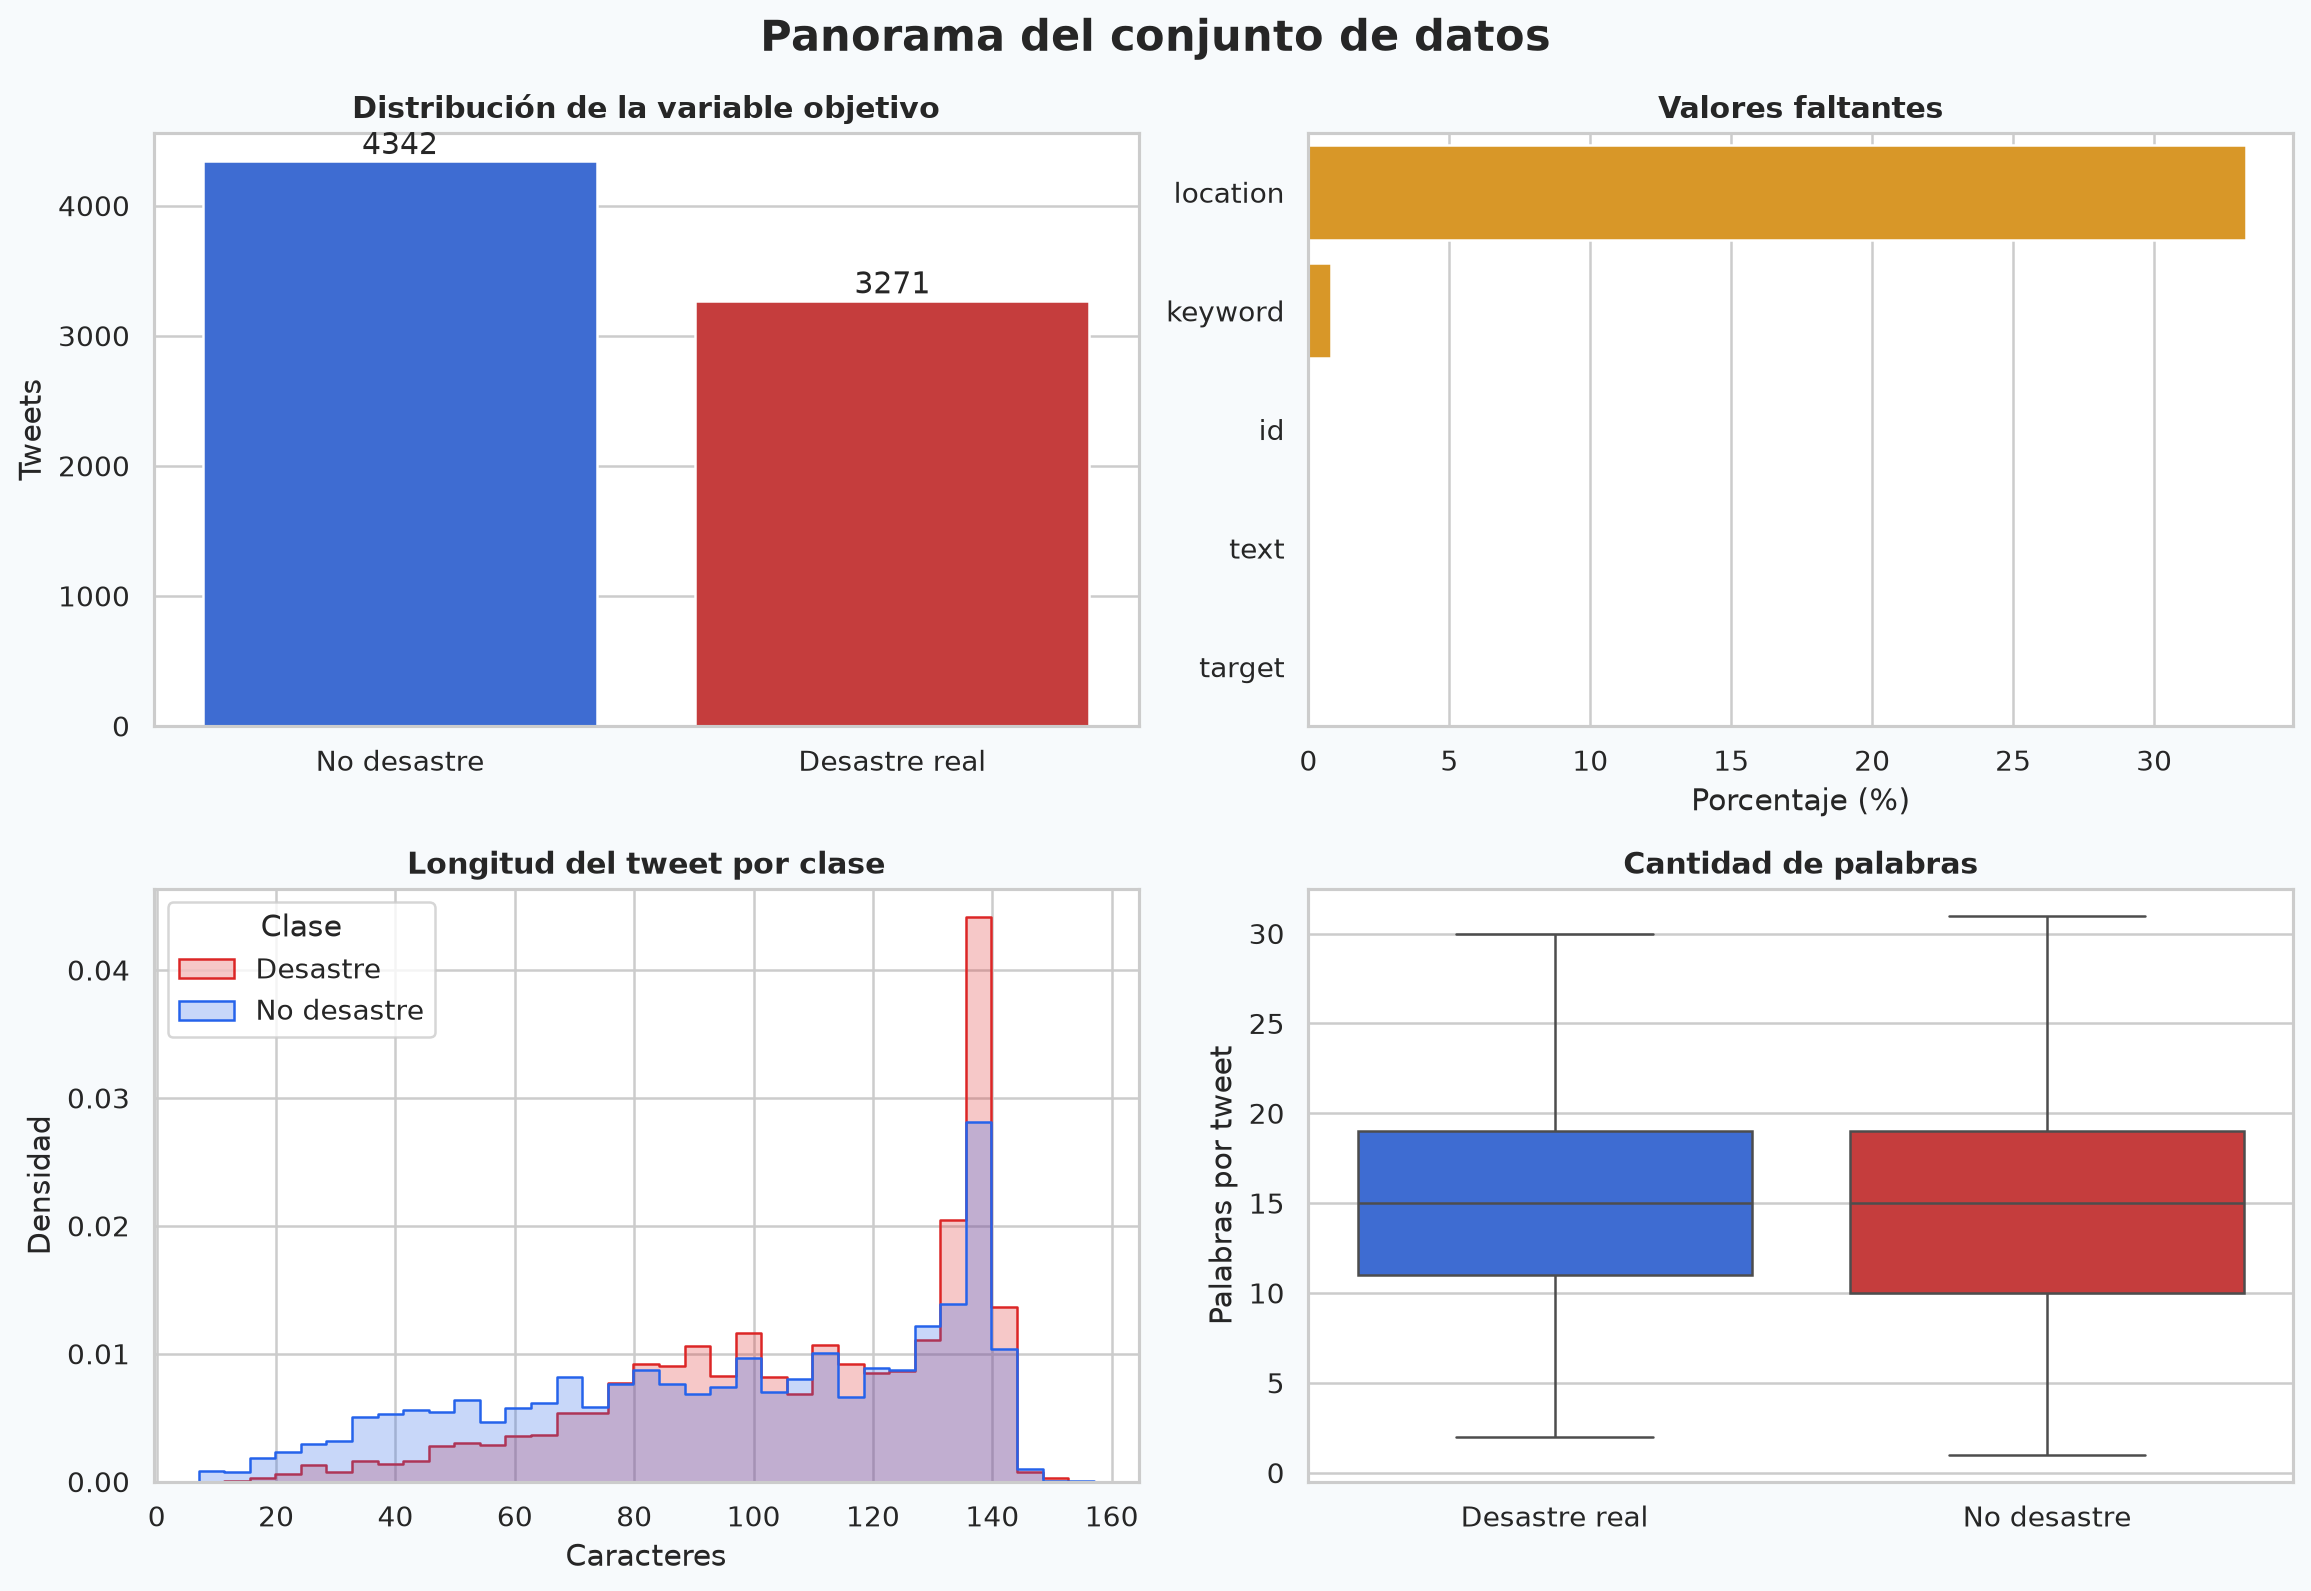

In [2]:
distribution = pd.read_csv(TABLES / "distribucion_target.csv")
schema = pd.read_csv(TABLES / "dataset_esquema.csv")
display(HTML("<h3>Distribución de la variable objetivo</h3>"))
display(distribution.style.format({"porcentaje": "{:.2f}%"}))
display(HTML("<h3>Esquema y valores faltantes</h3>"))
display(schema)
display(Image(filename=str(FIGURES / "eda_panorama.png"), width=1050))

El corpus contiene **7,613 tweets**: 4,342 (57.03%) no describen un desastre real y 3,271 (42.97%) sí. El desbalance es moderado, por lo que se usa partición estratificada y se reportan F1, recall, F1 macro y ROC-AUC además de exactitud. `location` es principalmente un campo auxiliar: su ausencia no impide explotar el texto.

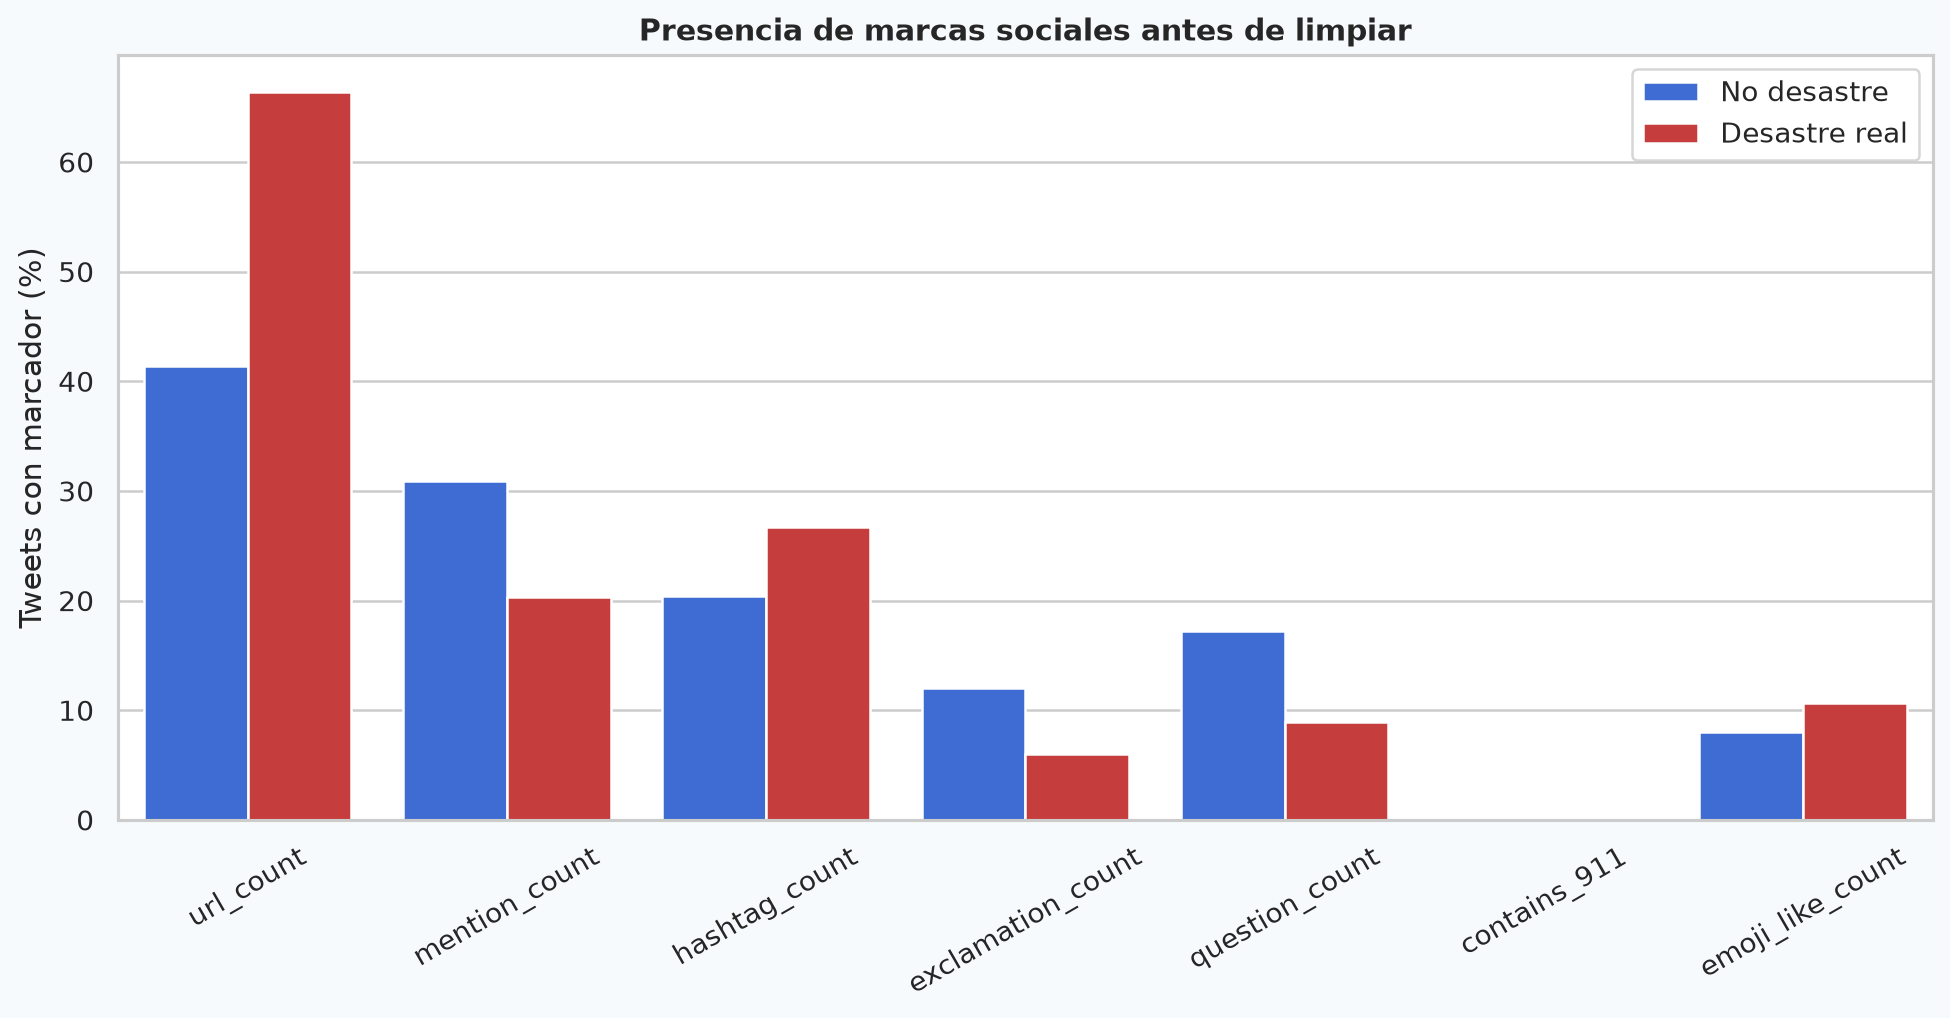

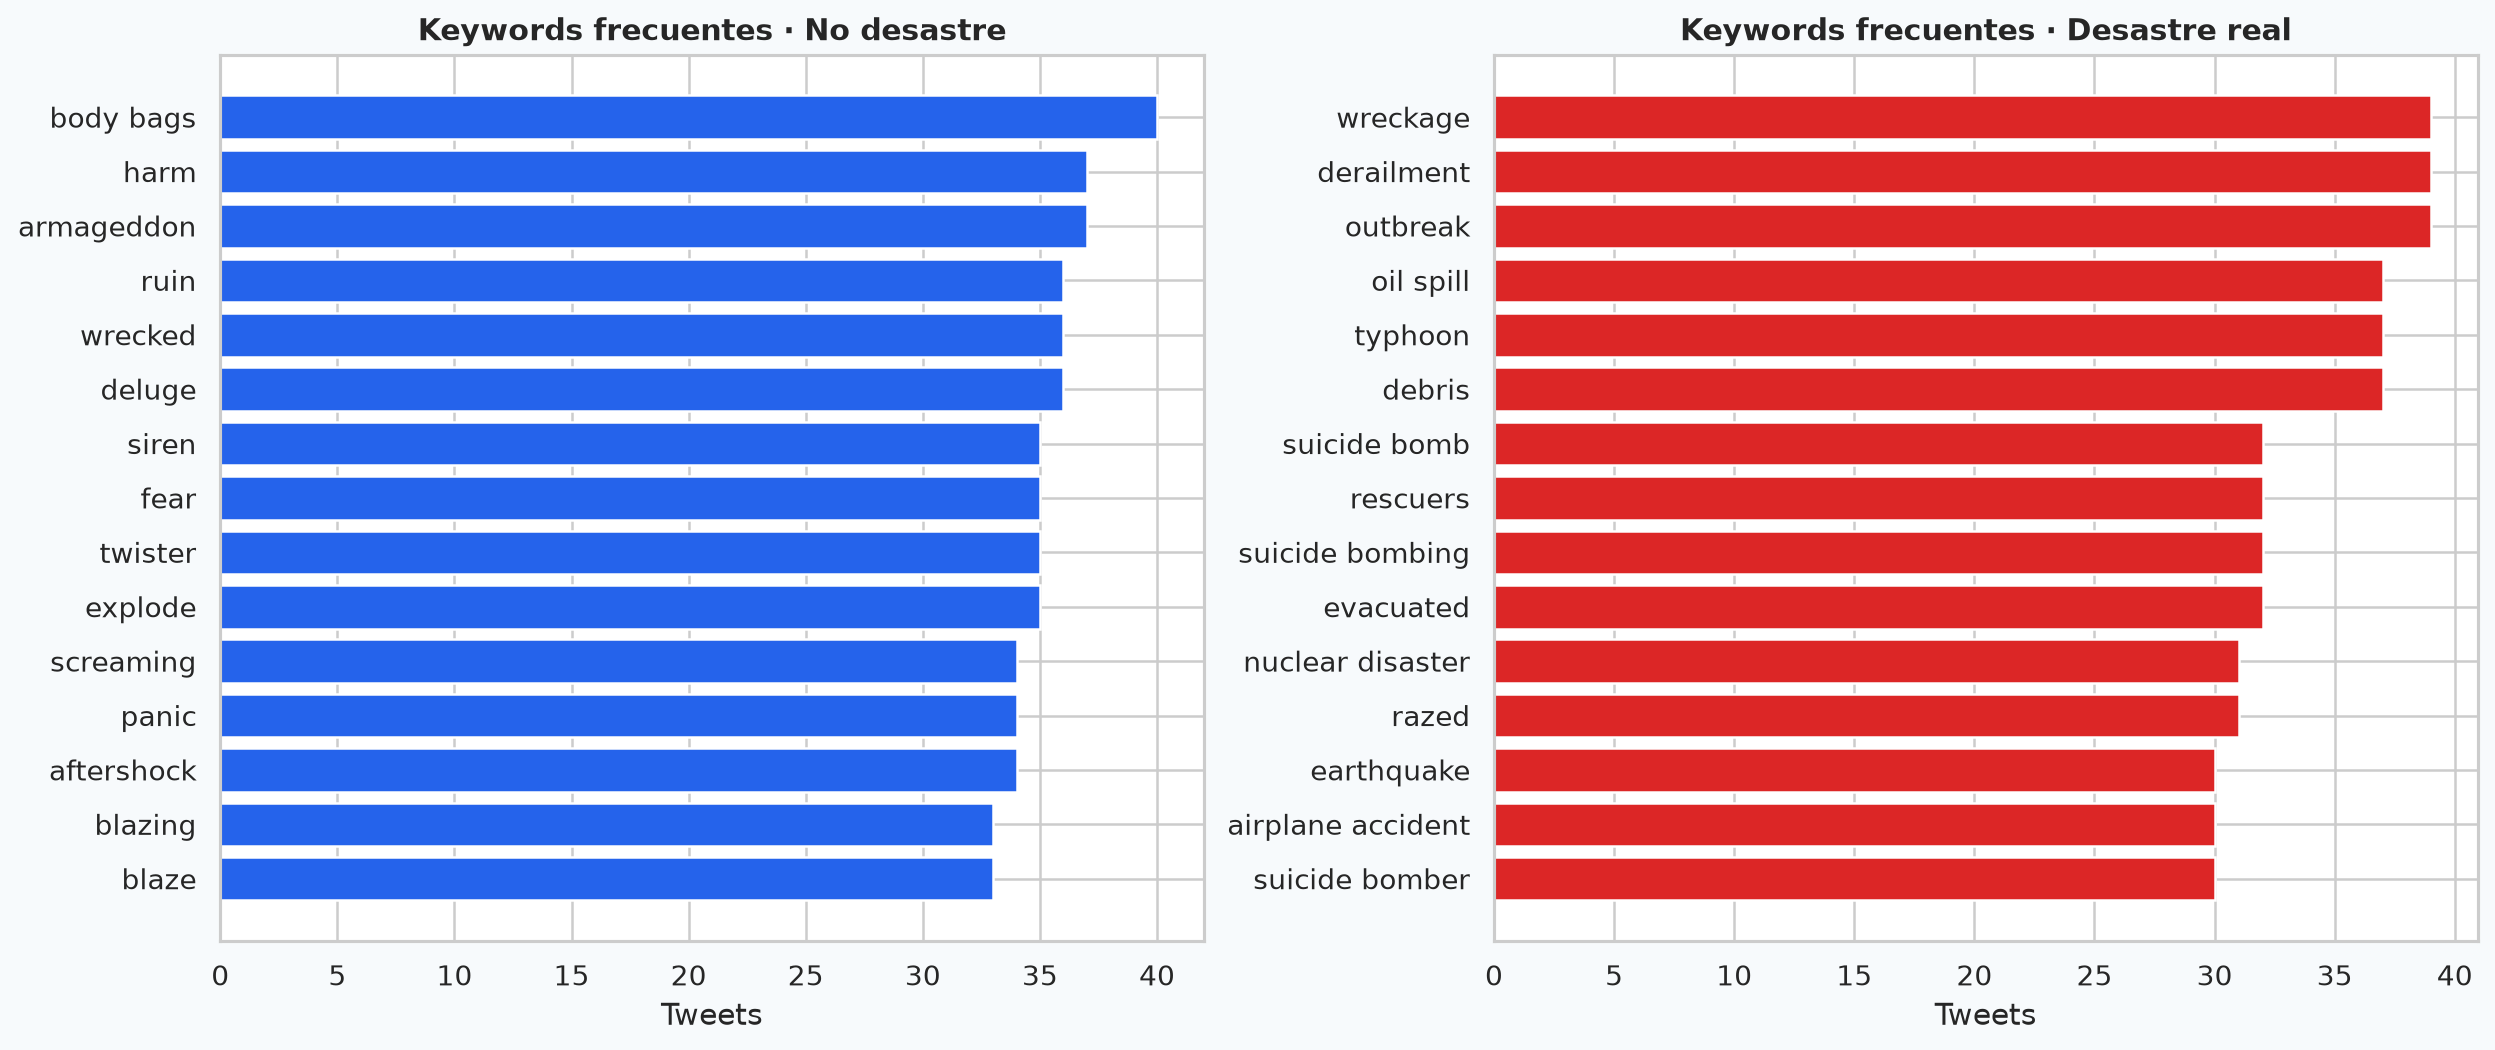

In [3]:
display(Image(filename=str(FIGURES / "eda_marcadores_sociales.png"), width=1000))
display(Image(filename=str(FIGURES / "eda_keywords.png"), width=1000))

<div class="section"><h2>3 · Preprocesamiento auditable</h2></div>

Se crean dos representaciones con propósitos distintos:

1. **Clasificación:** minúsculas, contracciones expandidas, eliminación de URL y menciones, conservación de la palabra del hashtag, eliminación de puntuación/dígitos y stopwords. Las negaciones (`no`, `not`, `never`) y el token `911` se preservan porque tienen información semántica.
2. **Sentimiento:** limpieza ligera; conserva puntuación, emojis y negaciones para no borrar señales afectivas que VADER necesita.

Esta separación evita el error metodológico de calcular sentimiento sobre texto excesivamente depurado.

In [4]:
examples = pd.read_csv(TABLES / "ejemplos_preprocesamiento.csv")
audit = pd.read_csv(TABLES / "auditoria_limpieza.csv")
display(examples[["target", "text", "clean_text"]].head(8))
display(HTML("<h3>Controles automáticos de limpieza</h3>"))
display(audit)

,target,text,clean_text
0,1,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake allah forgive
1,1,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
2,1,Just got sent this photo from Ruby #Alaska as ...,just got sent photo ruby alaska smoke wildfire...
3,1,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
4,1,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
5,1,Haha South Tampa is getting flooded hah- WAIT ...,haha south tampa getting flooded hah wait seco...
6,1,#raining #flooding #Florida #TampaBay #Tampa 1...,raining flooding florida tampabay tampa days l...
7,1,#Flood in Bago Myanmar #We arrived Bago,flood bago myanmar arrived bago


,indicador,valor
0,tweets_totales,7613.000000
1,texto_original_vacio,0.000000
2,texto_limpio_vacio,5.000000
3,palabras_original_promedio,14.903586
4,palabras_limpias_promedio,8.185472
5,tweets_con_url,3971.000000
6,tweets_con_mencion,2009.000000
7,tweets_con_hashtag,1761.000000
8,tweets_con_911,4.000000
9,texto_limpio_con_911,4.000000


<div class="section"><h2>4 · N-gramas y probabilidades</h2></div>

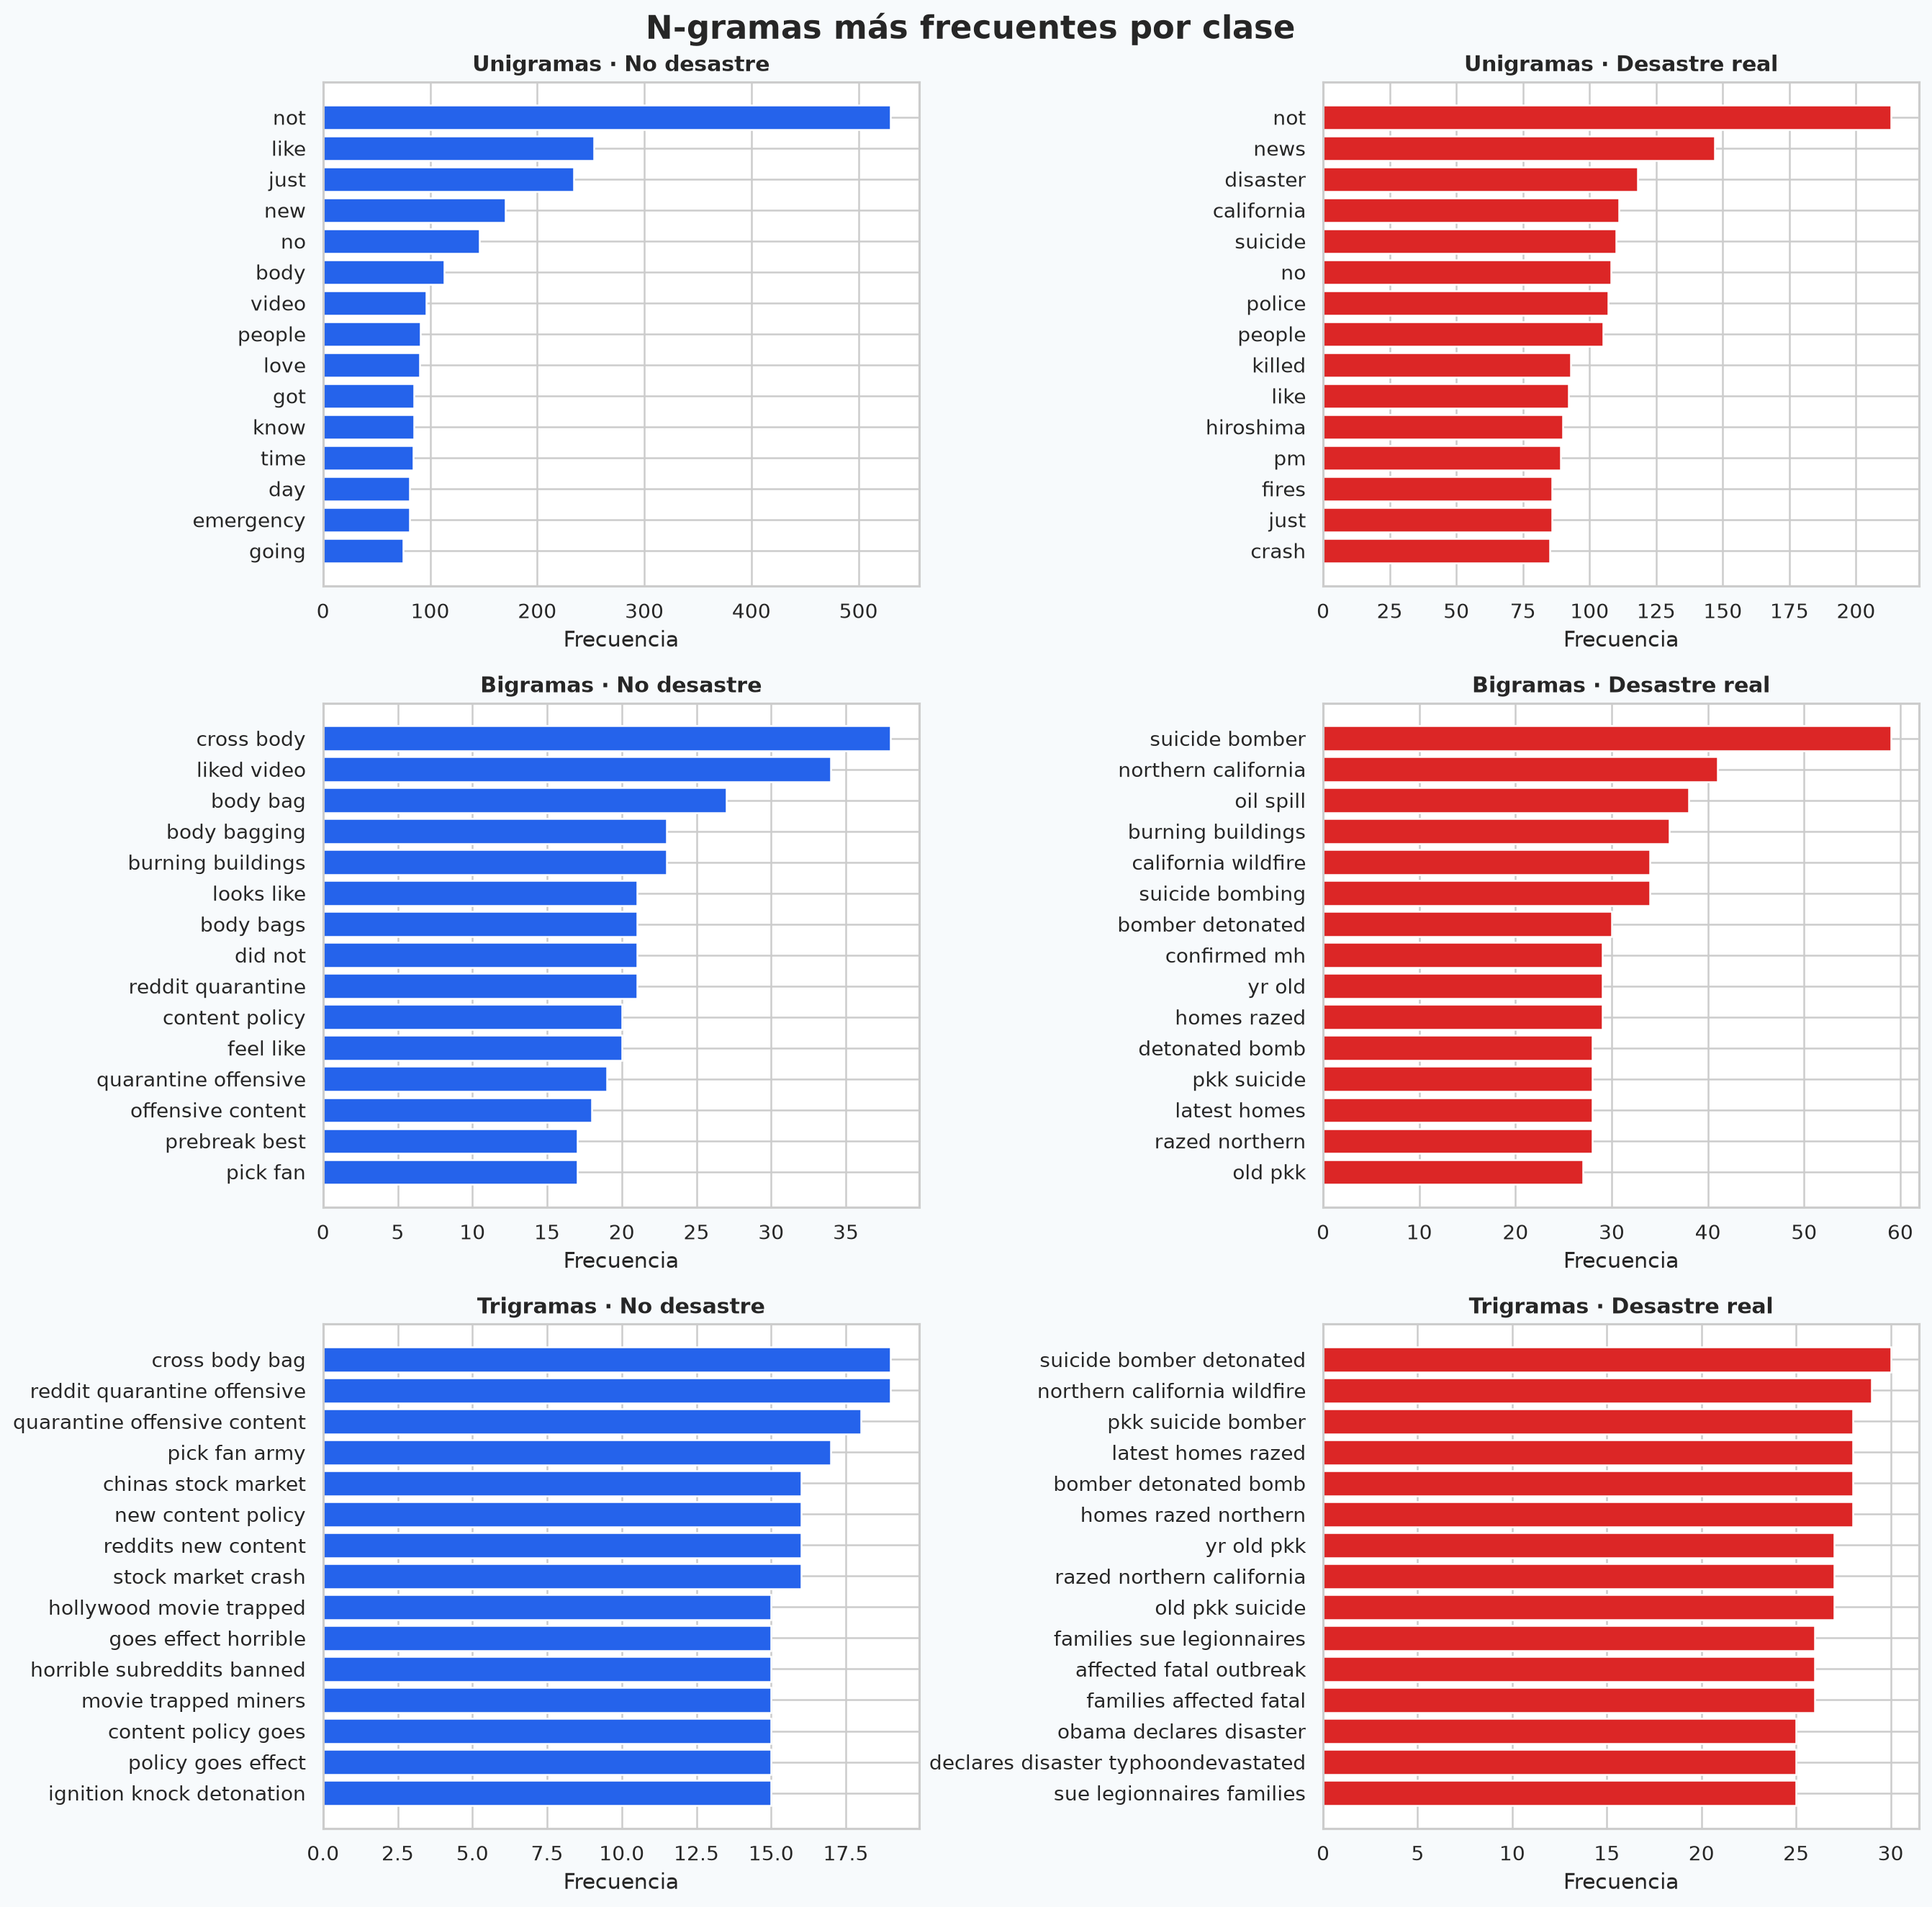

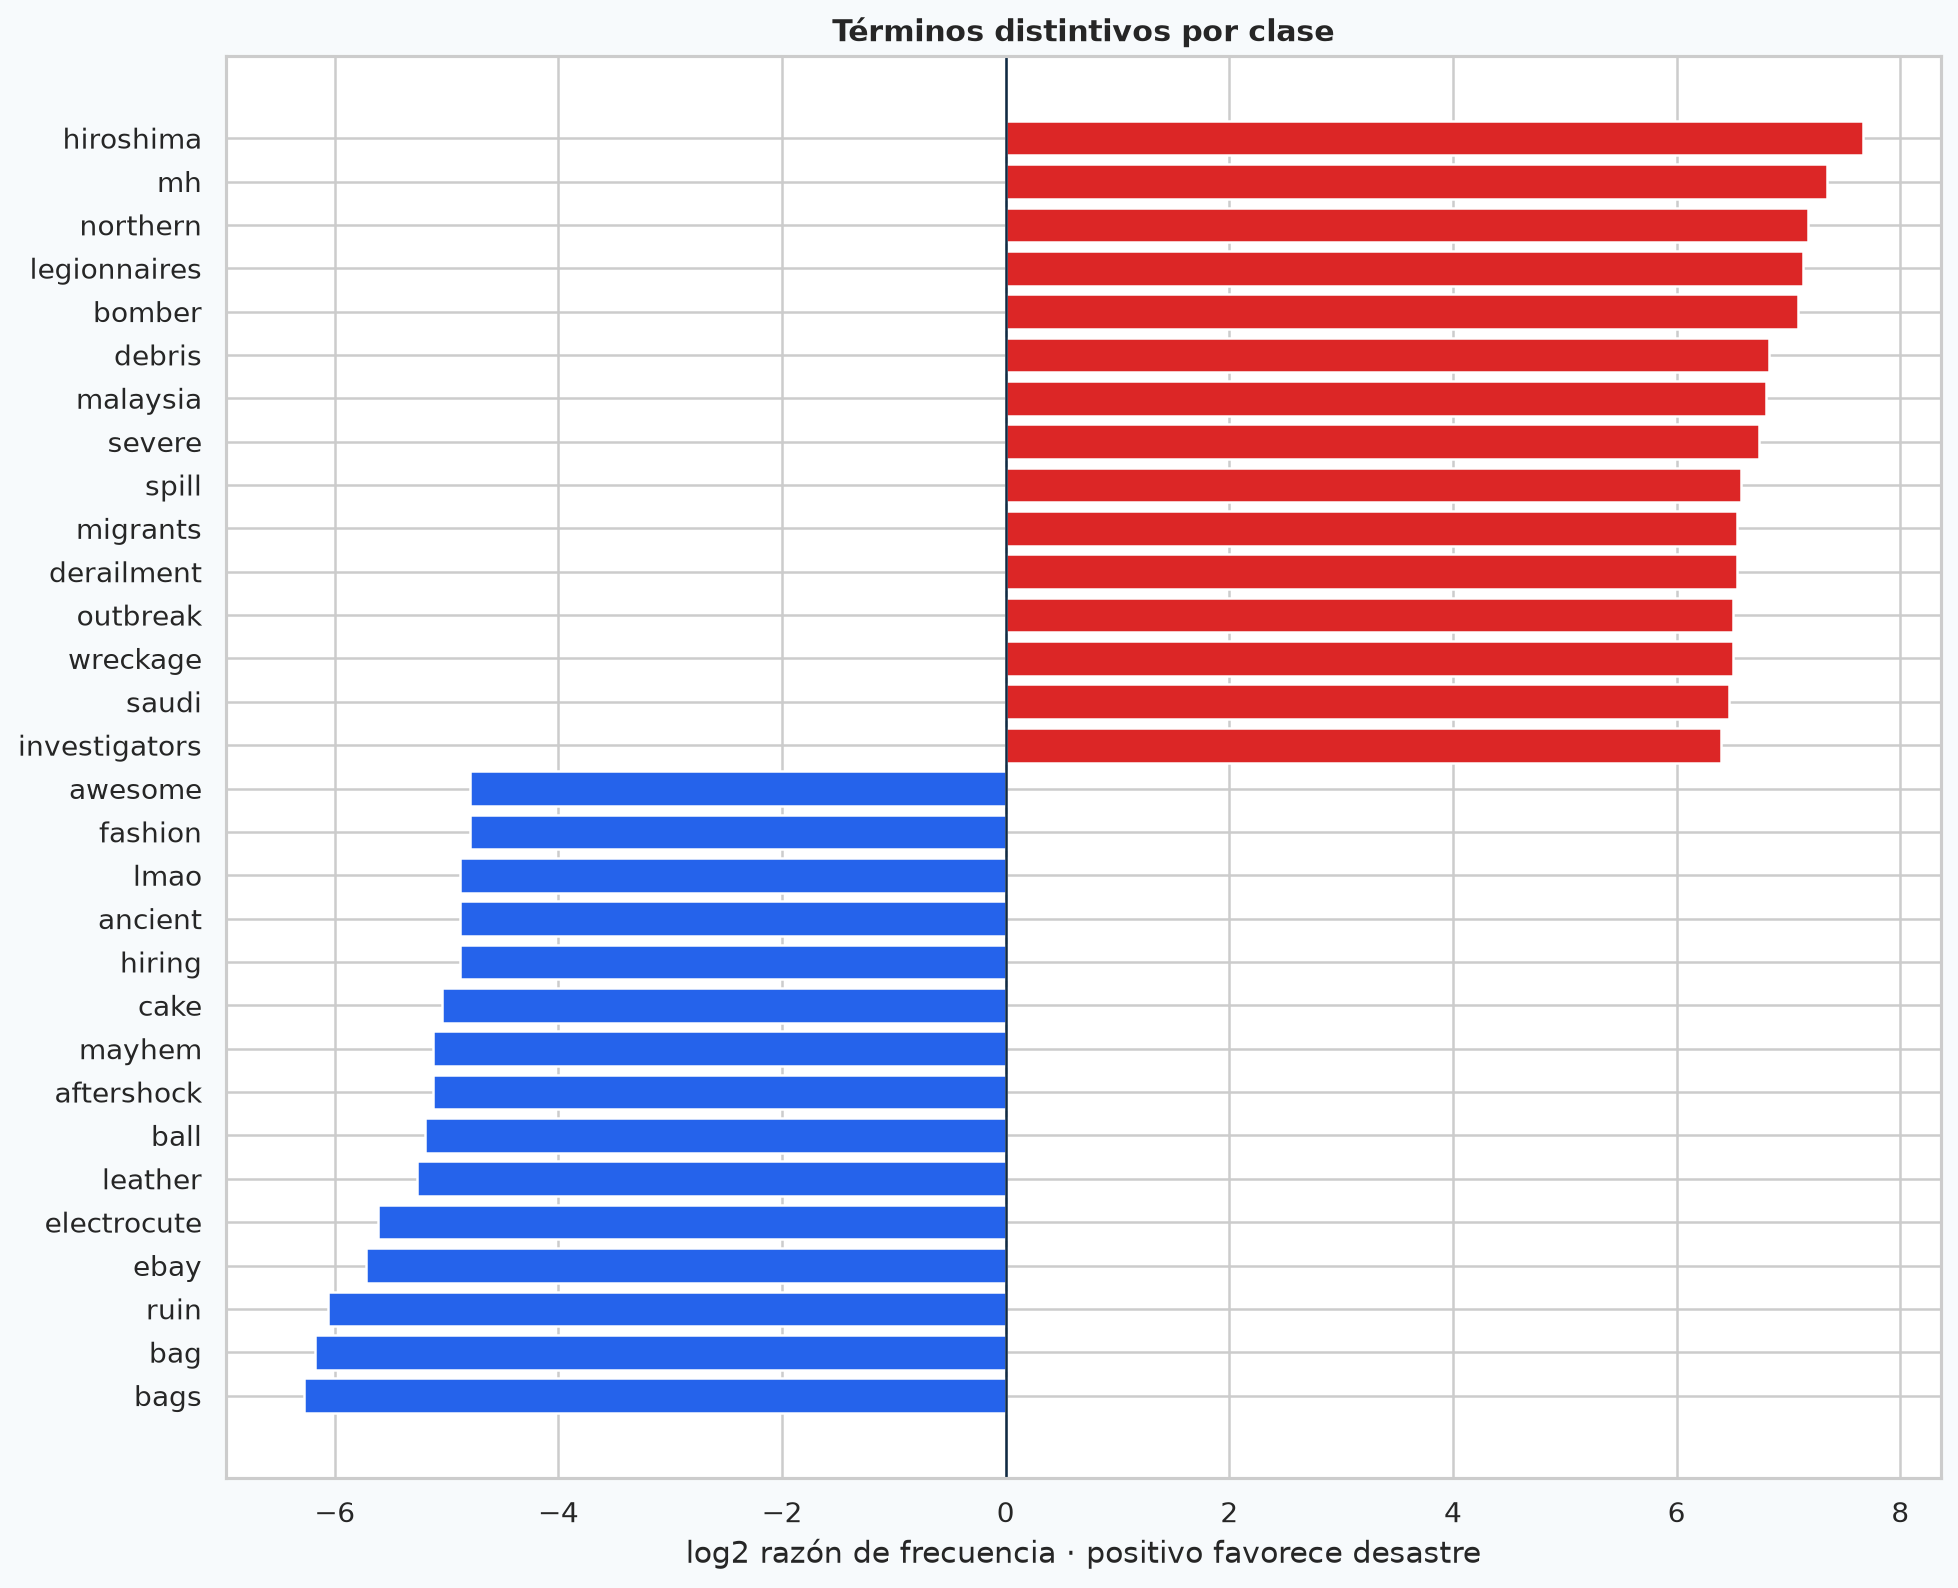

In [5]:
display(Image(filename=str(FIGURES / "ngramas_por_clase.png"), width=1100))
display(Image(filename=str(FIGURES / "unigramas_distintivos.png"), width=1000))

Para cada clase y orden (n), la probabilidad empírica se calcula como

\[
P(g\mid c)=\frac{f(g,c)}{\sum_{g'}f(g',c)}.
\]

No se confunde frecuencia bruta con probabilidad: ambos valores están disponibles en los CSV. Los bigramas como *suicide bomber*, *oil spill* y *northern california* concentran contexto más específico para desastre que palabras aisladas. El cociente logarítmico suavizado complementa el ranking y señala vocabulario distintivo de cada clase.

,ngram,frecuencia,probabilidad,n,target
0,cross body,38,0.5843%,2,0
1,liked video,34,0.5228%,2,0
2,body bag,27,0.4152%,2,0
3,burning buildings,23,0.3537%,2,0
4,body bagging,23,0.3537%,2,0
5,looks like,21,0.3229%,2,0
6,reddit quarantine,21,0.3229%,2,0
7,did not,21,0.3229%,2,0
8,body bags,21,0.3229%,2,0
9,content policy,20,0.3076%,2,0


,ngram,frecuencia,probabilidad,n,target
0,suicide bomber,59,0.5893%,2,1
1,northern california,41,0.4095%,2,1
2,oil spill,38,0.3795%,2,1
3,burning buildings,36,0.3596%,2,1
4,suicide bombing,34,0.3396%,2,1
5,california wildfire,34,0.3396%,2,1
6,bomber detonated,30,0.2996%,2,1
7,homes razed,29,0.2897%,2,1
8,confirmed mh,29,0.2897%,2,1
9,yr old,29,0.2897%,2,1


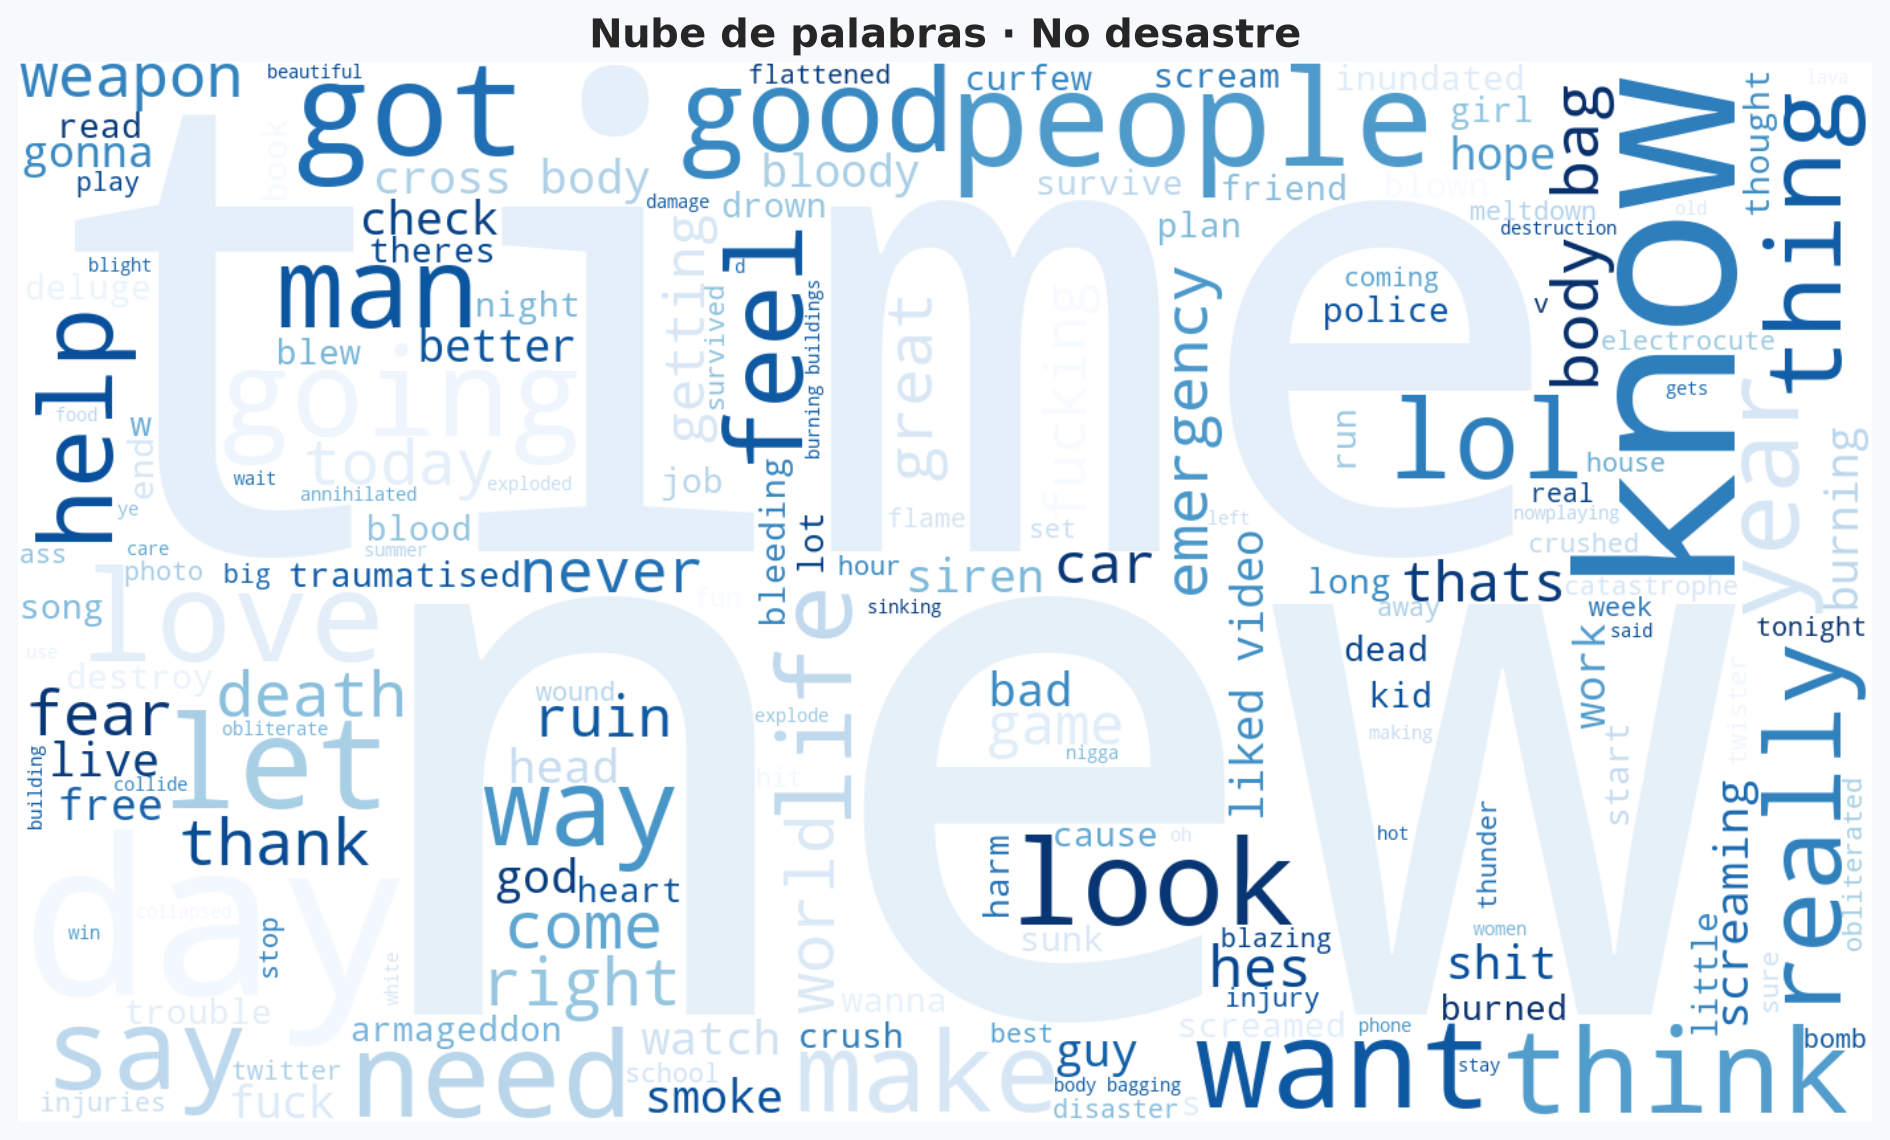

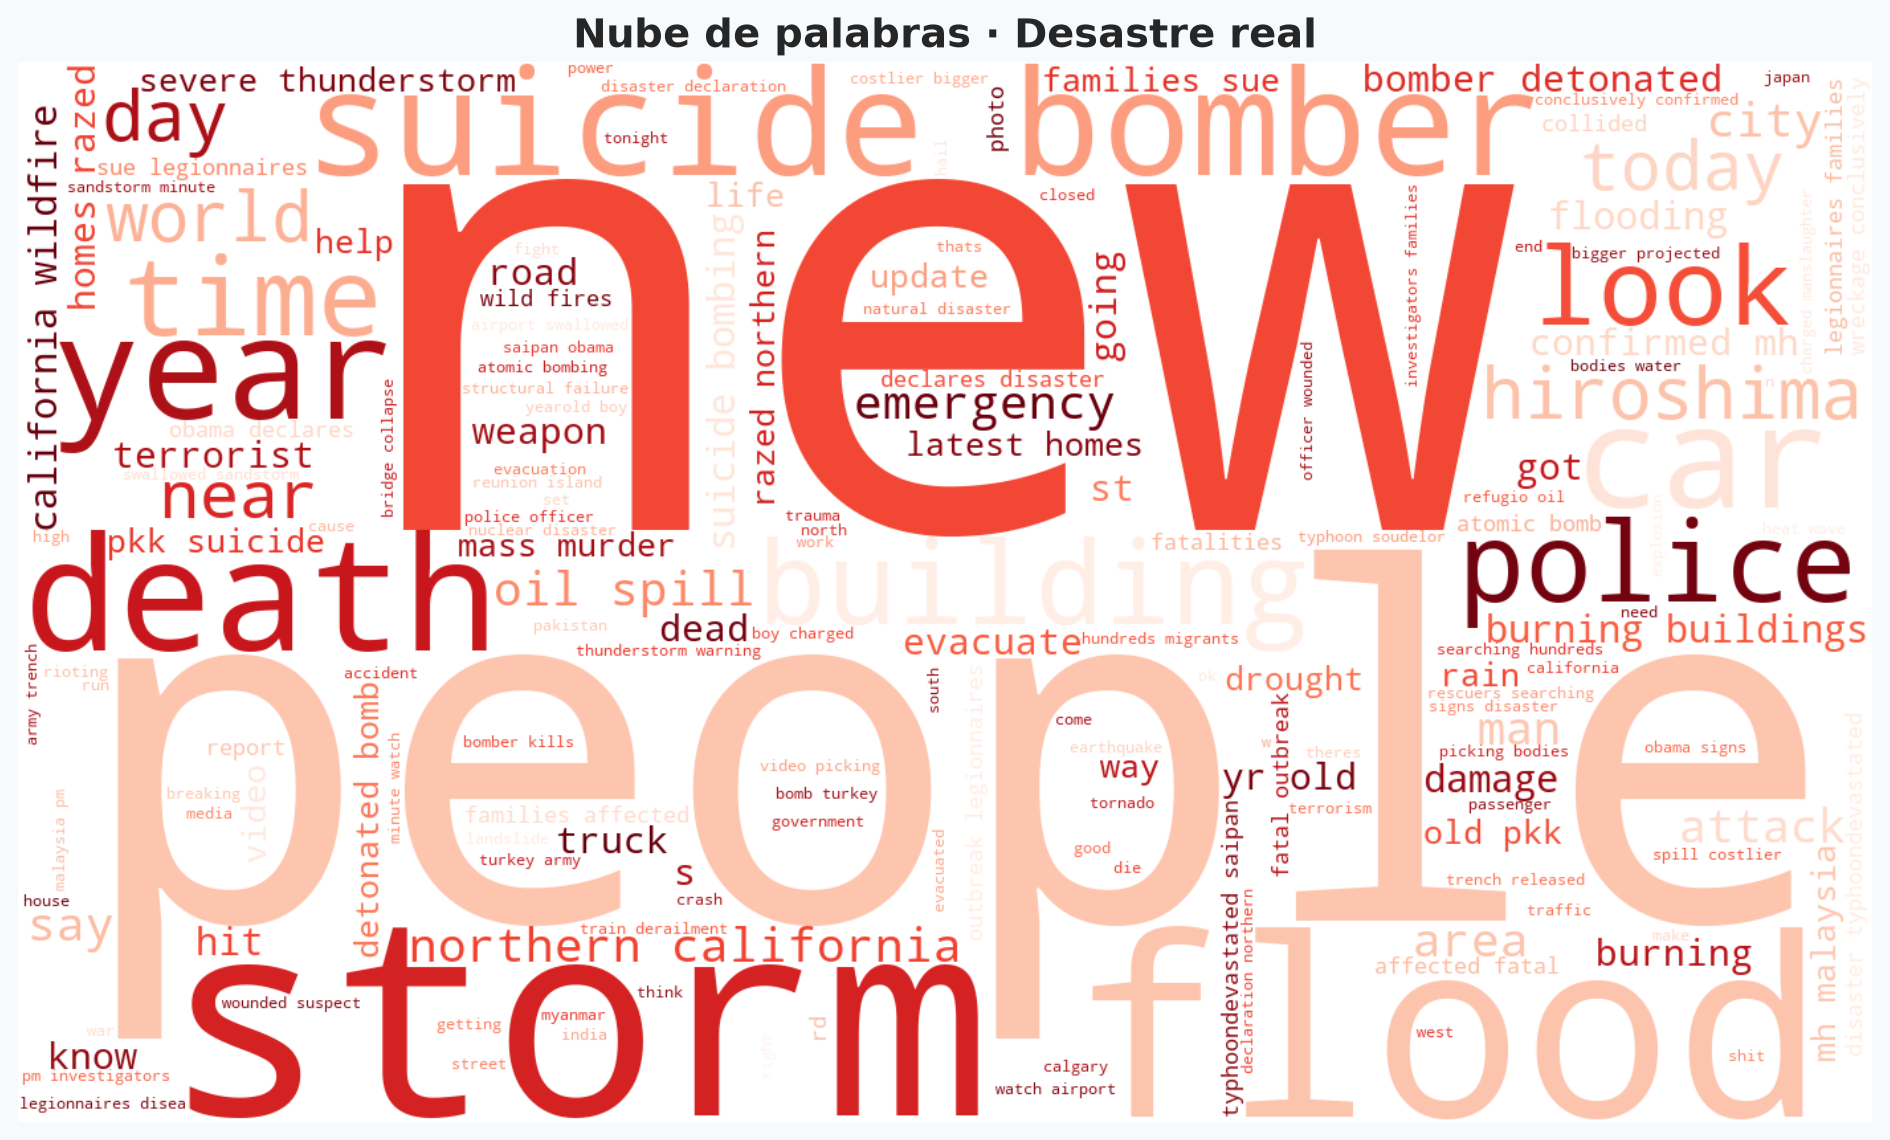

In [6]:
for target, label in [(0, "No desastre"), (1, "Desastre real")]:
    table = pd.read_csv(TABLES / f"bigramas_target_{target}.csv").head(10)
    display(HTML(f"<h3>{label}: diez bigramas principales</h3>"))
    display(table.style.format({"probabilidad": "{:.4%}"}))

display(Image(filename=str(FIGURES / "nube_palabras_target_0.png"), width=850))
display(Image(filename=str(FIGURES / "nube_palabras_target_1.png"), width=850))

<div class="section"><h2>5 · Modelos preliminares</h2></div>

,modelo,accuracy,precision,recall,f1,f1_macro,roc_auc,tn,fp,fn,tp,n_train,n_test
0,Regresión logística,0.813,0.785,0.777,0.781,0.809,0.867,730,139,146,508,6090,1523
1,SVM lineal calibrado,0.810,0.807,0.731,0.767,0.803,0.861,755,114,176,478,6090,1523
2,Naive Bayes complementario,0.807,0.800,0.734,0.766,0.801,0.864,749,120,174,480,6090,1523
3,Baseline mayoritaria,0.571,0.000,0.000,0.000,0.363,0.500,869,0,654,0,6090,1523


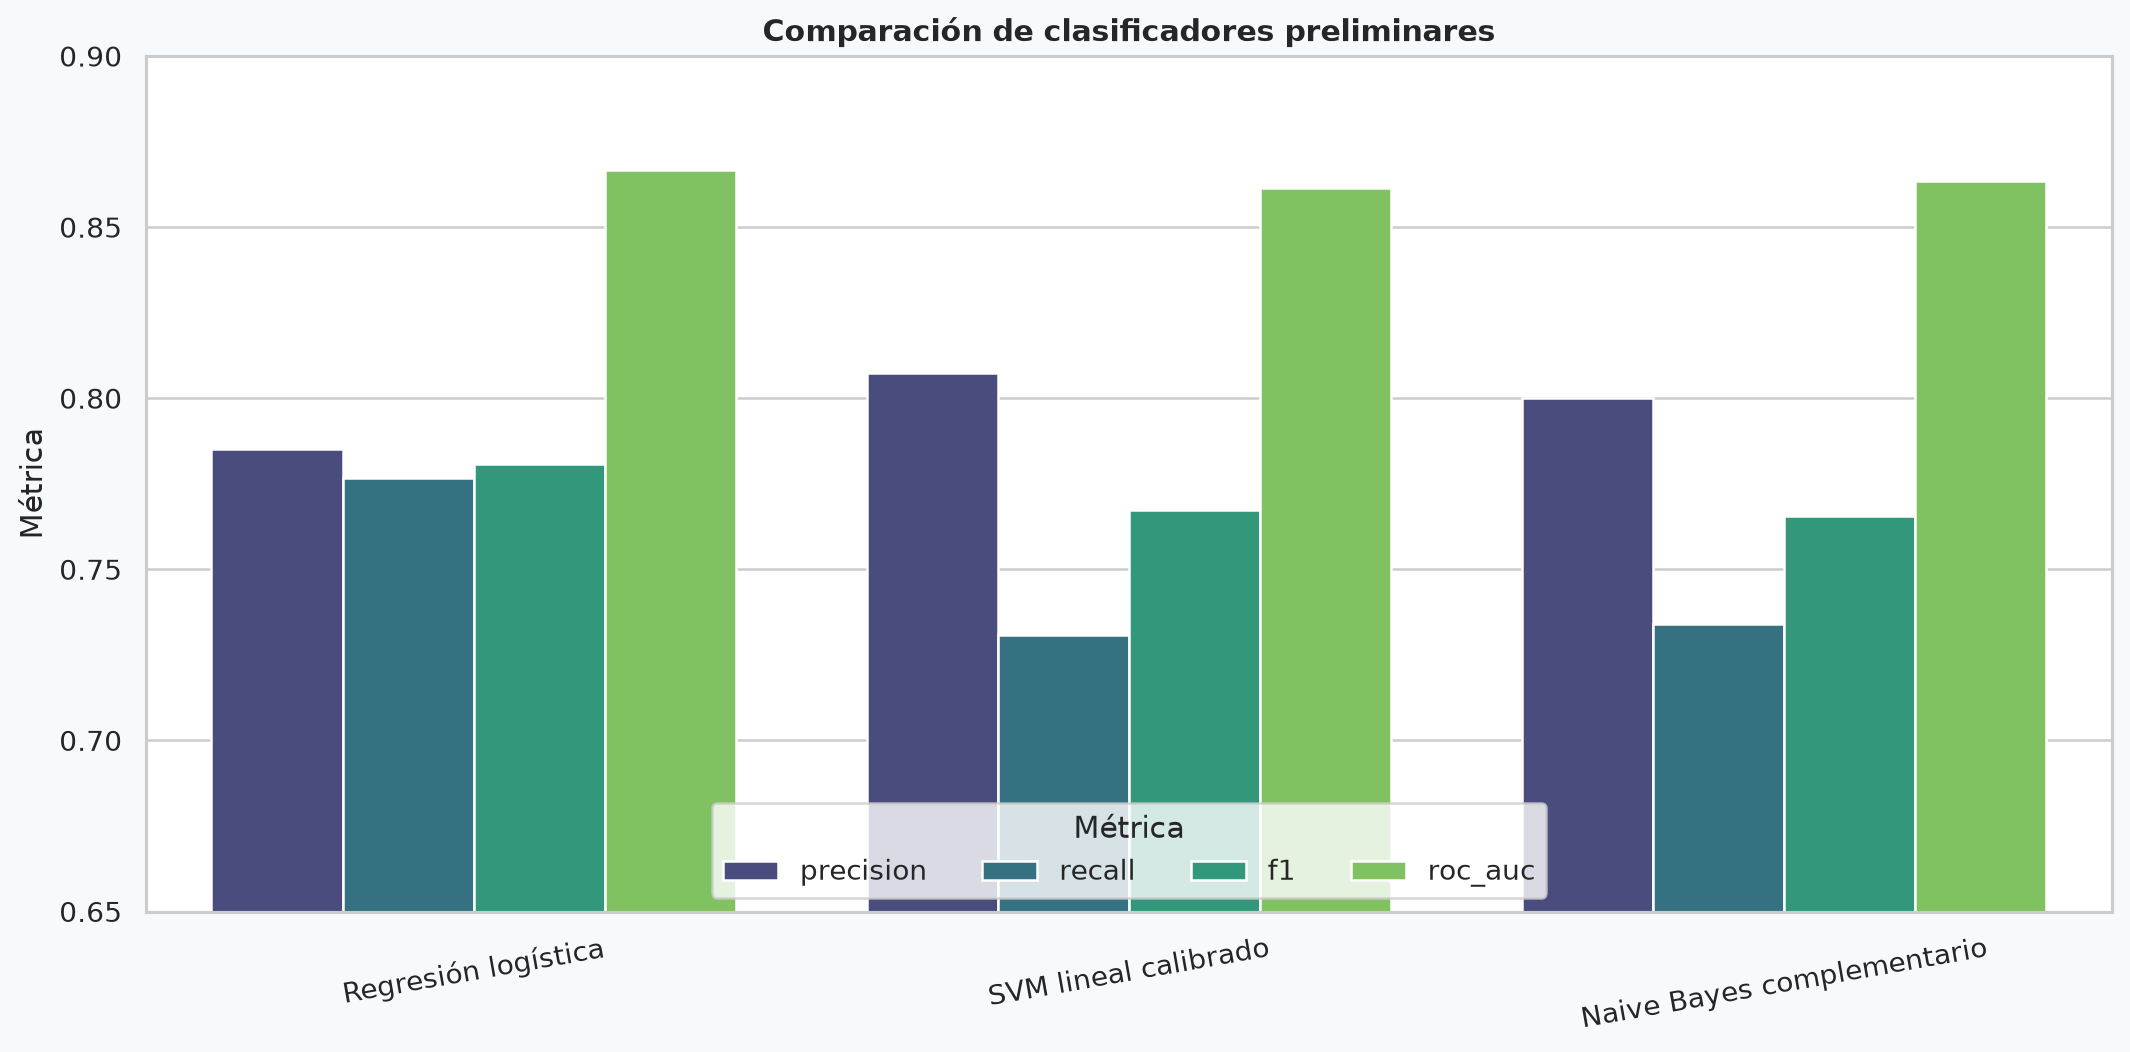

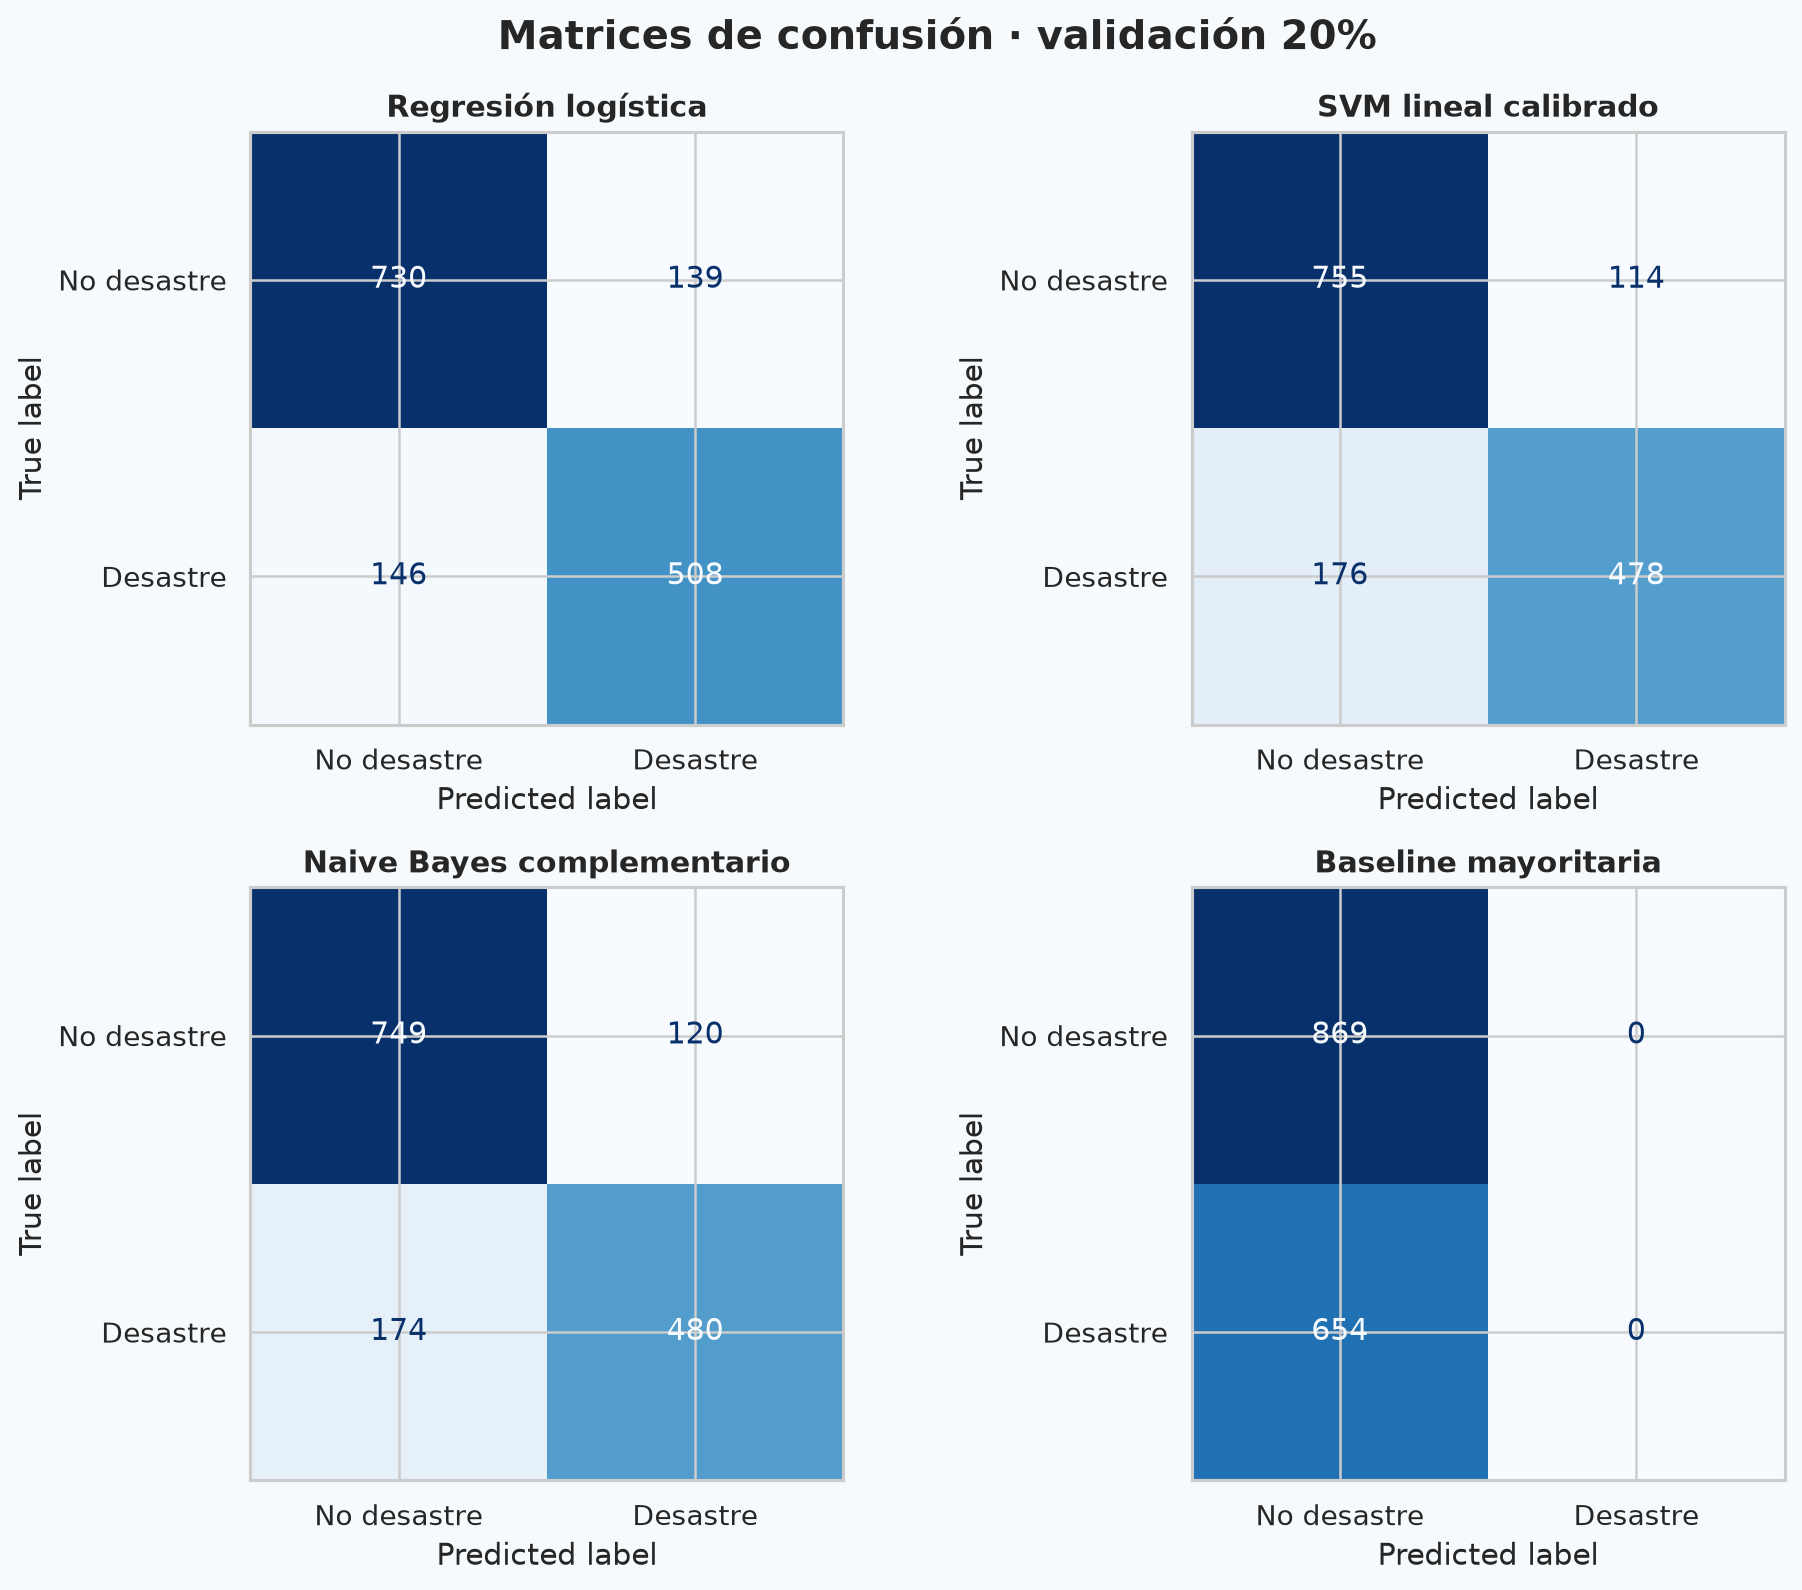

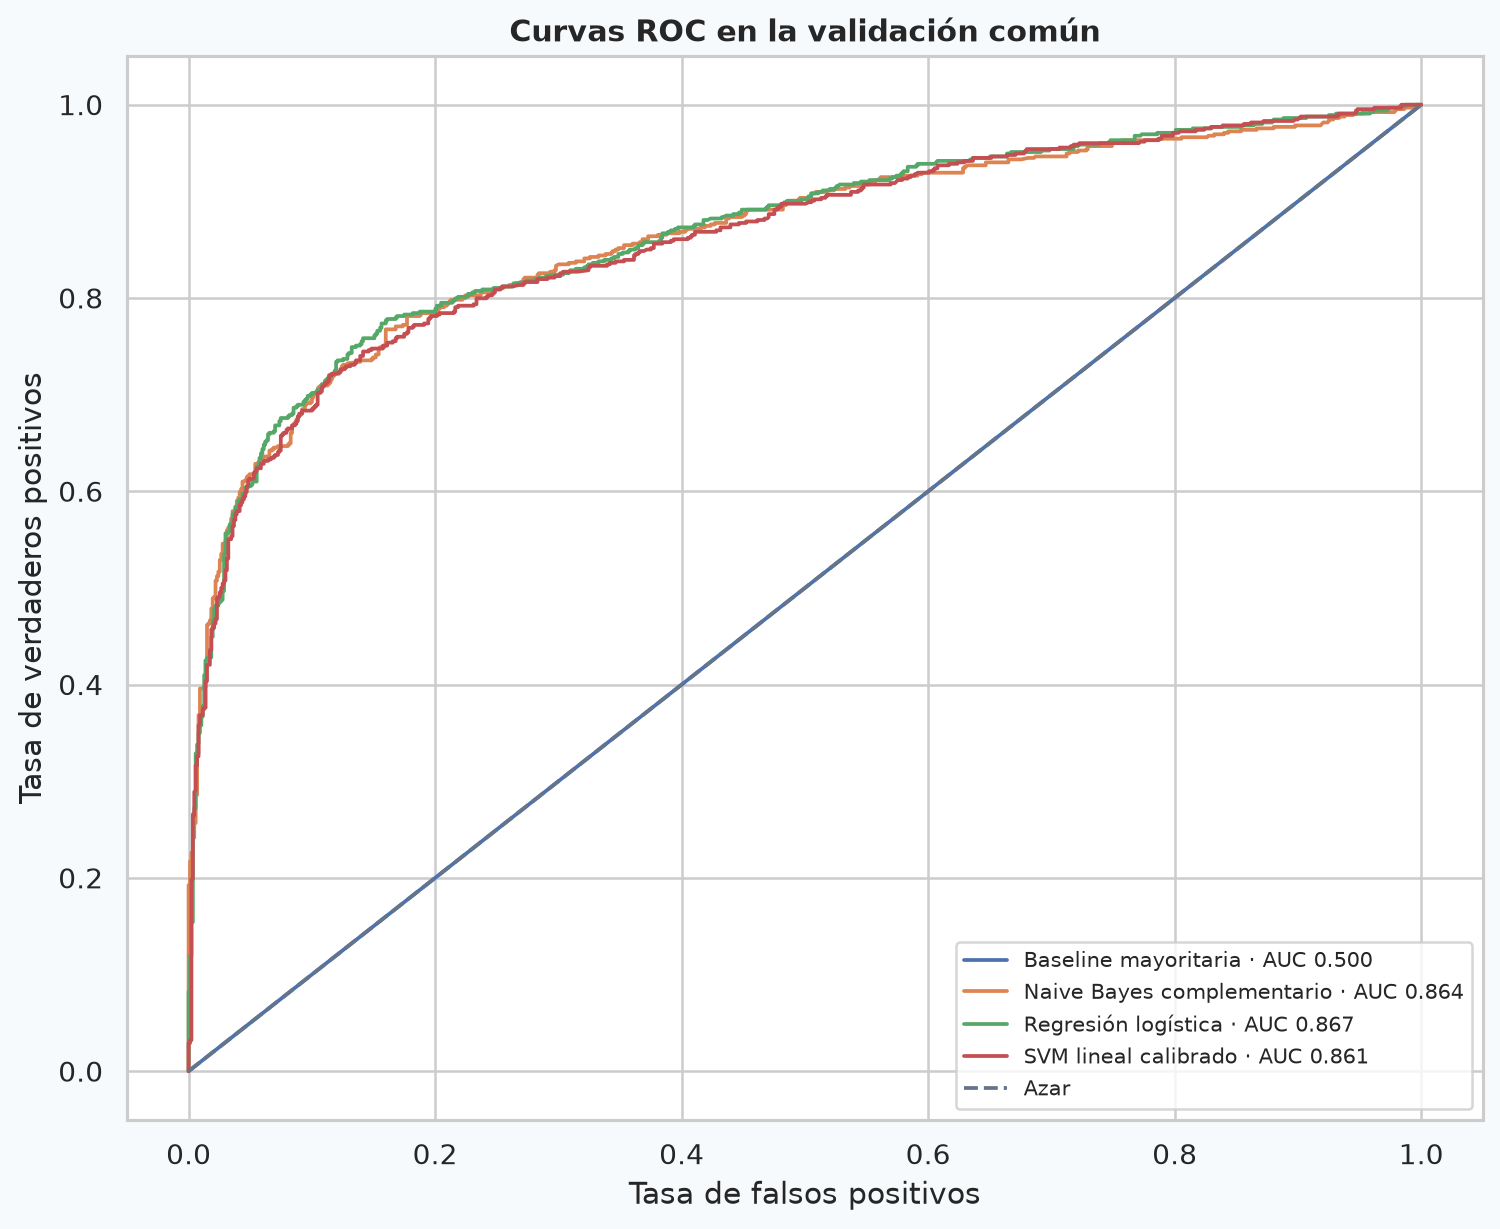

In [7]:
metrics = pd.read_csv(TABLES / "metricas_modelos_preliminares.csv")
best = metrics.iloc[0]
summary_html = (
    '<div class="metric-grid">'
    f'<div class="metric"><span>Mejor modelo</span><b style="font-size:1rem">{best["modelo"]}</b></div>'
    f'<div class="metric"><span>Exactitud</span><b>{best["accuracy"]:.2%}</b></div>'
    f'<div class="metric"><span>F1 desastre</span><b>{best["f1"]:.3f}</b></div>'
    f'<div class="metric"><span>ROC-AUC</span><b>{best["roc_auc"]:.3f}</b></div>'
    '</div>'
)
display(HTML(summary_html))
display(metrics.style.format({c: "{:.3f}" for c in ["accuracy", "precision", "recall", "f1", "f1_macro", "roc_auc"]}))
display(Image(filename=str(FIGURES / "modelos_comparacion.png"), width=1000))
display(Image(filename=str(FIGURES / "modelos_matrices_confusion.png"), width=1100))
display(Image(filename=str(FIGURES / "modelos_curvas_roc.png"), width=900))

Los cuatro modelos usan la misma división estratificada 80/20 (`random_state=42`): 6,090 observaciones para entrenamiento y 1,523 para prueba. La **regresión logística** obtiene el mejor F1 (0.781), con recall 0.777 y ROC-AUC 0.867. El SVM calibrado es ligeramente más preciso (0.807) cuando predice desastre, pero deja más falsos negativos. Esta es una selección preliminar; la afinación definitiva forma parte del 25% final.

<div class="section"><h2>6 · Función para clasificar tweets nuevos</h2></div>

In [8]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from lab5_text.modeling import predict_tweet

model = joblib.load(ROOT / "models" / "modelo_preliminar.joblib")
analyzer = SentimentIntensityAnalyzer()
samples = [
    "Massive fire near the city, residents are evacuating now!",
    "That movie was a total disaster lol 😂",
    "Emergency services report flooding on the highway.",
]
predictions = pd.DataFrame([predict_tweet(model, text, analyzer) for text in samples])
display(predictions.style.format({"probabilidad_desastre": "{:.2%}", "polaridad": "{:.3f}"}))

,texto,texto_limpio,clase,probabilidad_desastre,sentimiento,polaridad
0,"Massive fire near the city, residents are evacuating now!",massive near city residents evacuating,Desastre real,87.66%,negativo,-0.400
1,That movie was a total disaster lol 😂,movie total disaster lol,No desastre,35.27%,positivo,0.149
2,Emergency services report flooding on the highway.,emergency services report flooding highway,Desastre real,75.30%,negativo,-0.382


La función recibe **texto crudo**, aplica internamente el preprocesamiento y devuelve una clase comprensible junto con su probabilidad. El ejemplo de la película demuestra por qué la palabra *disaster* por sí sola no basta: el contexto completo disminuye la probabilidad de desastre real.

<div class="section"><h2>7 · Sentimiento exploratorio</h2></div>

,target,count,mean,median,std
0,0,4342,-0.052,0.000,0.466
1,1,3271,-0.266,-0.318,0.435


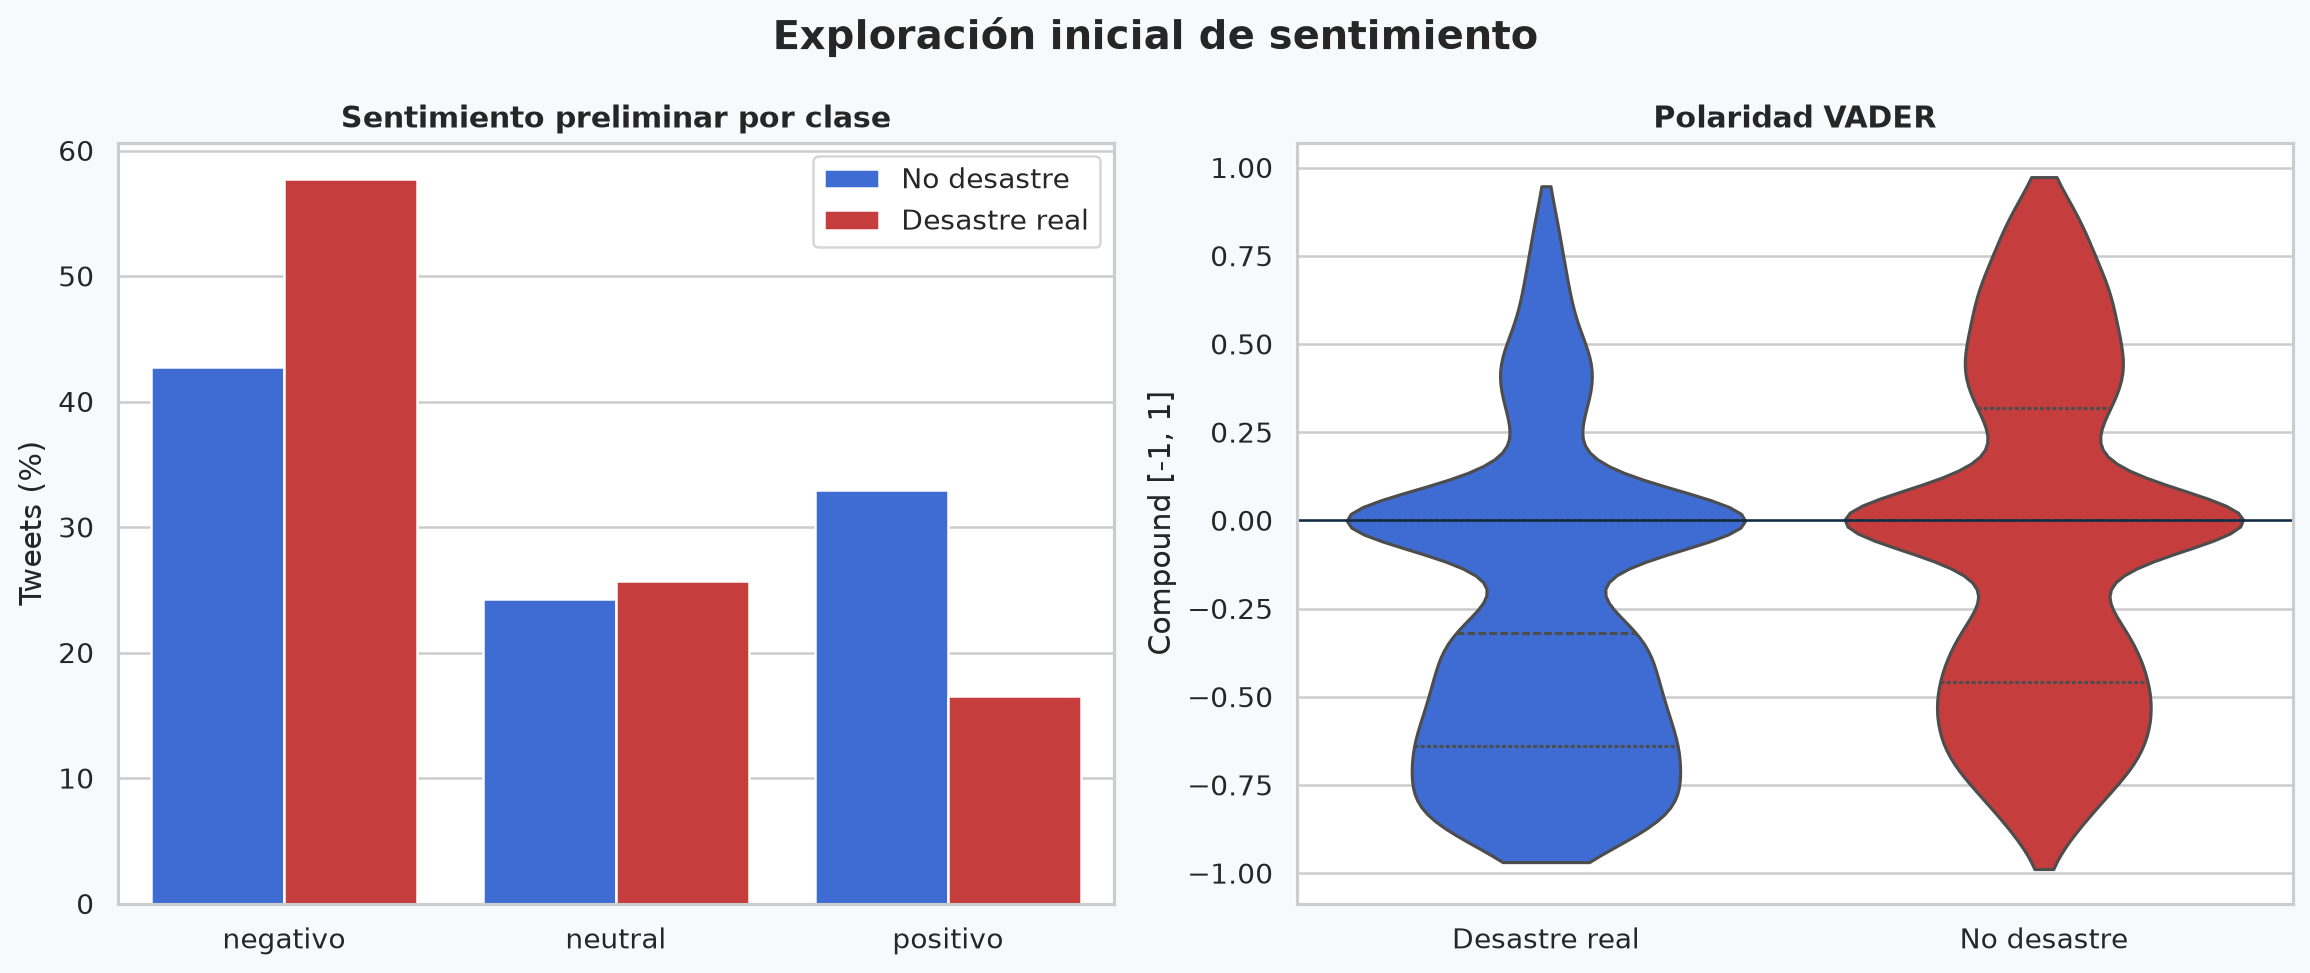

In [9]:
sentiment_summary = pd.read_csv(TABLES / "sentimiento_resumen_por_clase.csv")
display(sentiment_summary.style.format({"mean": "{:.3f}", "median": "{:.3f}", "std": "{:.3f}"}))
display(Image(filename=str(FIGURES / "sentimiento_exploratorio.png"), width=1050))

La polaridad media es más negativa en tweets de desastre real (−0.266) que en los que no lo son (−0.052). En este avance se presenta como evidencia descriptiva, no causal: la comparación formal, los diez extremos y el análisis de la variable de negatividad se reservan para la entrega final.

<div class="section"><h2>8 · Estado del avance</h2></div>
<div class="note"><b>Completado (75%)</b><br>Datos y EDA; limpieza auditable; unigramas, bigramas y trigramas con probabilidades; nubes de palabras; cuatro modelos comparables; métricas y errores; función de inferencia; sentimiento descriptivo inicial.</div>
<br>
<div class="pending"><b>Reservado para la entrega final (25%)</b><br>Top 10 positivo/negativo con interpretación; contraste estadístico por clase; ingeniería de la variable de negatividad y reentrenamiento; ajuste final, análisis de errores y conclusiones definitivas.</div>

### Conclusión provisional

El texto permite separar tweets de desastres reales con un desempeño sustancialmente superior al baseline. La regresión logística ofrece el mejor equilibrio preliminar y constituye una base transparente para la fase final, en la que se probará si el sentimiento aporta señal predictiva incremental.